# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [1]:
from IPython.display import SVG, display, Image
import matplotlib.pyplot as plt

import os

# Replace '/path/to/new/cache' with your desired directory
os.environ["HF_HOME"] = "./.cache"
print(os.environ["HF_HOME"])

from datasets import load_dataset, concatenate_datasets, DatasetDict, Value

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


from torch.optim import AdamW
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm
from scipy.optimize import curve_fit


import re
import time

import mup
from mup import MuReadout, make_base_shapes, set_base_shapes, MuSGD, MuAdam

./.cache


c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\pl_bolts\__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
c:\Users\Vince\miniconda3\envs\neuroinfo\Lib\site-packages\pl_bolts\models\self_supervised\amdim\amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lig

# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [2]:
dataset_3 = load_dataset("starvector/svg-stack-simple")
dataset_3 = dataset_3.cast_column("Filename", Value("string"))

# Combine all splits using a dictionary comprehension
combined_dataset = DatasetDict(
    {
        split: concatenate_datasets(
            # [dataset_1[split], dataset_2[split], dataset_3[split]]
            [dataset_3[split]]
        )
        # for split in dataset_1.keys()
        for split in dataset_3.keys()
    }
)

total_items = 300000

dataset = combined_dataset["train"].select(range(total_items))

print(dataset)

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 300000
})


## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [3]:
def clean_svg(svg_text):
    # 1. Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # 2. Function to clean ONLY the path data string
    def clean_path_data(match):
        path_string = match.group(1)

        # Space out the letters (M, L, C, Z, etc.)
        path_string = re.sub(r"([a-zA-Z])", r" \1 ", path_string)

        # Replace commas with spaces
        path_string = path_string.replace(",", " ")

        # Round numbers to 1 decimal place
        def round_match(m):
            try:
                return f"{float(m.group(0)):.1f}"
            except ValueError:
                return m.group(0)

        path_string = re.sub(r"-?\d*\.?\d+", round_match, path_string)

        # Clean up any messy double-spaces inside the quotes
        path_string = re.sub(r"\s+", " ", path_string).strip()

        # Return it wrapped back in d="..."
        return f'd="{path_string}"'

    # 3. Apply the cleaner ONLY to the d="..." attributes
    svg_text = re.sub(r'd="([^"]+)"', clean_path_data, svg_text)

    # 4. Clean up any overall messy whitespace
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text

### Clean and verify all svgs in training set


In [4]:
TOKEN_THRESHOLD = 2048

In [5]:
from svg_utils import process_row

In [6]:
print("Cleaning datasets with multiprocessing...")
cleaned_dataset = dataset.map(process_row, num_proc=8)
print("Done!")

remaining_items = len(cleaned_dataset)
print(remaining_items)

Cleaning datasets with multiprocessing...
Done!
300000


In [7]:
stop_1 = int(remaining_items * 0.98)
stop_2 = stop_1 + int(remaining_items * 0.01)
stop_3 = stop_2 + int(remaining_items * 0.01)

cleaned_train = cleaned_dataset.select(range(stop_1))
cleaned_val = cleaned_dataset.select(range(stop_1, stop_2))
cleaned_test = cleaned_dataset.select(range(stop_2, stop_3))

In [8]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


filtered_train = cleaned_train.filter(is_valid)

In [9]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 204630


## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [10]:
# small initials

VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [11]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [12]:
try:
    tokenizer = Tokenizer.from_file("tokenizer.json")
except:
    print("No tokenizer found in root!")

    tokenizer = Tokenizer(models.BPE())

    tokenizer.pre_tokenizer = pre_tokenizers.Sequence(
        [pre_tokenizers.WhitespaceSplit(), pre_tokenizers.Punctuation()]
    )

    trainer = trainers.BpeTrainer(
        special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
    )

    tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

    tokenizer.save("tokenizer.json")

In [13]:
# sample_2 = filtered_train["Svg"][0]
# sample_2

In [14]:
# encoded_sample_2 = tokenizer.encode(sample_2)

# print(encoded_sample_2)


# # First 10 tokens on encoding
# for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
#     print(f"{id} -> {token}")

In [15]:
# tokenizer.decode(encoded_sample_2.ids)

In [16]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [17]:
tokenized_train = filtered_train.map(tokenize_svg)

In [18]:
# tokenized_train["input_ids"]

In [19]:
print("Flattening tokenized_dataset (PyArrow backend)...")

# .data accesses the PyArrow table
# .combine_chunks() ensures the memory is contiguous
# .flatten() removes the sub-lists instantaneously
# .to_numpy() creates a zero-copy NumPy array
train_input_ids = (
    tokenized_train.data["input_ids"].combine_chunks().flatten().to_numpy()
)

print(f"Done! Shape: {train_input_ids.shape}")

Flattening tokenized_dataset (PyArrow backend)...
Done! Shape: (130428077,)


In [20]:
print(f"len(np.unique(train_input_ids)): {len(np.unique(train_input_ids))}")

len(np.unique(train_input_ids)): 940


### Create, clean, filter, and tokenize test/val datasets


In [21]:
print("Preparing val and test dataset")

filtered_test = cleaned_test.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)  # , num_proc=8)
test_input_ids = tokenized_test.data["input_ids"].combine_chunks().flatten().to_numpy()
test_input_ids = np.array(test_input_ids)

filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)  # , num_proc=8)
val_input_ids = tokenized_val.data["input_ids"].combine_chunks().flatten().to_numpy()
val_input_ids = np.array(val_input_ids)

Preparing val and test dataset


In [22]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 133084710
Number of tokens in train: 130428077 -> 98.00%
Number of tokens in val: 1355632 -> 1.02%
Number of tokens in test: 1301001 -> 0.98%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


## 2.0 Setup


### 2.0.0 Dataloaders


In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert to 1D tensors
train_data = torch.tensor(train_input_ids, dtype=torch.long)
val_data = torch.tensor(val_input_ids, dtype=torch.long)

# We want sequences of length (BLOCK_SIZE + 1)
# Assuming you still have BLOCK_SIZE = 256 from your earlier cell
seq_len = BLOCK_SIZE + 1


def chunk_data(data, seq_len):
    # Calculate how many full sequences we can make
    num_chunks = len(data) // seq_len

    # Truncate any leftover tokens at the very end that don't fit into a full chunk
    data = data[: num_chunks * seq_len]

    # Reshape the 1D tensor into a 2D grid of shape (num_chunks, seq_len)
    return data.view(num_chunks, seq_len)


# 2. Reshape 1D streams into 2D grids
train_data_2d = chunk_data(train_data, seq_len)
val_data_2d = chunk_data(val_data, seq_len)

# 3. NOW we can slice into X and Y safely!
# X gets everything except the last token of each chunk
X_train = train_data_2d[:, :-1]
# Y gets everything except the first token of each chunk
Y_train = train_data_2d[:, 1:]

X_val = val_data_2d[:, :-1]
Y_val = val_data_2d[:, 1:]

# 4. Bundle into TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(
    dataset=train_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    dataset=val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True
)

print(f"X Train shape: {X_train.shape}, Y Train shape: {Y_train.shape}")
print(f"X Val shape: {X_val.shape}, Y Val shape: {Y_val.shape}")

X Train shape: torch.Size([507502, 256]), Y Train shape: torch.Size([507502, 256])
X Val shape: torch.Size([5274, 256]), Y Val shape: torch.Size([5274, 256])


### 2.0.1 Define Model and Functions


In [24]:
# Keeping depth the same (n_layers, n_heads) and only varying width (d_model, d_ff)
configs = {
    "Tiny": {"d_model": 128, "n_layers": 6, "n_heads": 6, "d_ff": 512},
    "XL": {"d_model": 768, "n_layers": 6, "n_heads": 6, "d_ff": 3072},
}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 4. Best Model Training and Sample Generation


In Part 2, you tuned the learning rate on the smallest model and used it for all model sizes. In this part,
you will investigate whether µP (Maximal Update Parameterization) can improve scaling behavior by
enabling principled learning rate transfer across model widths. You will also use your scaling laws to make
predictions beyond the model sizes you trained.


## 3.1 Scaling Study


### 3.1.1 Reparameterize


In [25]:
class MuHead(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        self.head_size = head_size  # Store this

        # 'tril' is the lower triangular matrix for masking
        # self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (d_model)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # # Compute attention scores
        # wei = q @ k.transpose(-2, -1) * (self.head_size**-1)

        # # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        # wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        # output = F.softmax(wei, dim=-1) @ v

        output = F.scaled_dot_product_attention(
            q, k, v, is_causal=True, scale=1.0 / self.head_size
        )

        return output


class MuMultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()
        head_size = d_model // n_heads
        self.heads = nn.ModuleList(
            [MuHead(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):
        x = torch.concat([head(x) for head in self.heads], dim=-1)
        x = self.proj(x)
        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class MuTransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MuMultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class MuCustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                MuTransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = mup.MuReadout(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [26]:
name = "XL"  # Explicitly defining the name for your print statements and saving

# Initialize the proxy (Tiny) config
base_model = MuCustomTransformer(
    vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs["Tiny"]
).to(device)

# Initialize the model with the specific config
target_model = MuCustomTransformer(
    vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs[name]
).to(device)

mup.set_base_shapes(target_model, base_model)

state_dict = torch.load(
    f"mu_model_{name}_best.pt", map_location=device, weights_only=True
)
target_model.load_state_dict(state_dict)

# Set to evaluation mode
target_model.eval()
print("✅ Model loaded successfully!")


params = count_parameters(target_model)
print(f"Parameters: {params:,}")

✅ Model loaded successfully!
Parameters: 44,248,552


# Generate Samples


In [38]:
def generate_svg(
    model, tokenizer, prompt, max_new_tokens=256, temperature=1.0, top_k=None
):
    """Generates SVG text using temperature and Top-K sampling."""
    model.eval()

    # Encode the prompt
    input_ids = tokenizer.encode(prompt).ids
    idx = torch.tensor([input_ids], dtype=torch.long).to(device)
    # new_idx = model.generate(idx, max_new_tokens, temperature=temperature)

    eot_id = tokenizer.token_to_id("<|endoftext|>")

    with torch.inference_mode():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -model.block_size :]
            logits, _ = model(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Apply Top-K filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("Inf")

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

            if idx_next.item() == eot_id:
                break

    return tokenizer.decode(idx[0].tolist())

In [39]:
import re


def post_process_svg(svg_string):
    """Cleans up spaces injected by the tokenizer and closes truncated tags."""

    # 1. Fix basic brackets and slashes
    svg_string = re.sub(r"<\s+", "<", svg_string)
    svg_string = re.sub(r"\s+>", ">", svg_string)
    svg_string = re.sub(r"<\s*/\s*", "</", svg_string)
    svg_string = re.sub(r"/\s*>", "/>", svg_string)

    # 2. Fix decimals (e.g., 12 . 0 -> 12.0)
    svg_string = re.sub(r"\s*\.\s*", ".", svg_string)

    # 3. Fix equals signs and quotes
    svg_string = re.sub(r"\s*=\s*", "=", svg_string)
    svg_string = svg_string.replace('=" ', '="').replace(' "', '"')

    # 4. Fix hyphens in attribute names (e.g., "stroke - width" -> "stroke-width")
    svg_string = re.sub(r"\s*-\s*", "-", svg_string)

    # 5. Fix colons and slashes in xmlns URLs
    svg_string = re.sub(r"\s*:\s*", ":", svg_string)
    svg_string = svg_string.replace("http:// ", "http://")
    svg_string = svg_string.replace(" / ", "/")

    # --- 6. AUTO-CLOSING TRUNCATED TAGS ---
    # If the generation hit max_new_tokens, it will be cut off mid-string.

    # # Close open quotes
    # if svg_string.count('"') % 2 != 0:
    #     svg_string += '"'

    # # Close open path tags
    # if "<path" in svg_string and not (
    #     "/>" in svg_string.split("<path")[-1] or "</path>" in svg_string
    # ):
    #     svg_string += " />"

    # # Close the root svg tag
    # if "</svg>" not in svg_string:
    #     svg_string += "</svg>"

    # --- 7. ADD WHITE BACKGROUND ---
    # Injects a 100% width/height white rectangle right after the opening <svg ...> tag
    svg_string = re.sub(
        r"(<svg[^>]*>)",
        r'\1<rect width="100%" height="100%" fill="white"/>',
        svg_string,
        count=1,
    )

    return svg_string


def evaluate_and_render(svg_string, filename):
    """Checks XML validity and attempts to render using CairoSVG."""

    # --- CLEAN THE STRING FIRST ---
    svg_string = post_process_svg(svg_string)

    print(f"post_processed: {svg_string}")

    is_valid_xml = False
    is_renderable = False

    try:
        root = etree.fromstring(svg_string.encode("utf-8"))
        if root.tag.endswith("svg"):
            is_valid_xml = True
    except etree.XMLSyntaxError as e:
        pass

    if is_valid_xml:
        try:
            cairosvg.svg2png(bytestring=svg_string.encode("utf-8"), write_to=filename)
            is_renderable = True
            print(f"✅ Rendered successfully: {filename}")
            display(Image(filename=filename))
        except Exception as e:
            print(f"❌ Valid XML, but CairoSVG failed to render: {e}")
    else:
        print(f"❌ Invalid XML Structure")
        # Optional: print(svg_string) to see exactly where it failed!

    return is_valid_xml, is_renderable


--- Generating 10 Unconditional Samples ---
Generating Sample 1...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 13 . 6 1 . 5 14 . 9 2 . 0 15 . 7 2 . 9 C 16 . 6 3 . 7 17 . 1 4 . 9 17 . 4 6 . 6 L 17 . 4 9 . 3 L 18 . 8 9 . 3 C 19 . 3 9 . 5 19 . 9 10 . 1 20 . 1 10 . 6 L 20 . 1 15 . 4 L 20 . 1 20 . 1 C 19 . 9 20 . 7 19 . 3 21 . 2 18 . 8 21 . 5 L 12 . 0 21 . 5 L 5 . 2 21 . 5 C 4 . 7 21 . 2 4 . 1 20 . 7 3 . 9 20 . 1 L 3 . 9 15 . 4 L 3 . 9 10 . 6 C 4 . 1 10 . 1 4 . 7 9 . 5 5 . 2 9 . 3 L 6 . 6 9 . 3 L 6 . 6 6 . 6 C 6 . 9 4 . 9 7 . 4 3 . 7 8 . 3 2 . 9 C 9 . 1 2 . 0 10 . 4 1 . 5 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 3 

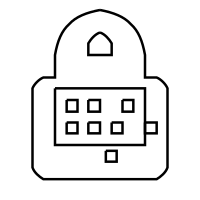

Generating Sample 2...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 13 . 9 1 . 4 15 . 8 1 . 8 17 . 4 2 . 7 C 18 . 9 3 . 5 20 . 3 4 . 8 21 . 3 6 . 5 C 22 . 4 8 . 3 22 . 8 10 . 2 22 . 8 12 . 1 C 22 . 7 13 . 9 22 . 2 15 . 7 21 . 3 17 . 3 C 20 . 4 18 . 9 19 . 1 20 . 3 17 . 5 21 . 3 C 15 . 9 22 . 2 14 . 0 22 . 8 12 . 0 22 . 8 C 10 . 0 22 . 8 8 . 1 22 . 2 6 . 5 21 . 3 C 4 . 9 20 . 3 3 . 6 18 . 9 2 . 7 17 . 3 C 1 . 8 15 . 7 1 . 3 13 . 9 1 . 2 12 . 1 C 1 . 2 10 . 2 1 . 6 8 . 3 2 . 7 6 . 5 C 3 . 7 4 . 8 5 . 1 3 . 5 6 . 6 2 . 7 C 8 . 2 1 . 8 10 . 1 1 . 4 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 8 . 0 7 . 0 L 8 . 0 7 . 0 C 8 . 2 

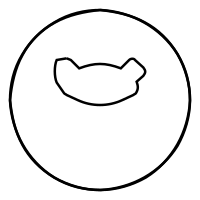

Generating Sample 3...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 12 . 2 1 . 3 12 . 4 1 . 3 12 . 6 1 . 4 L 17 . 0 3 . 7 L 21 . 5 5 . 9 C 21 . 8 6 . 4 21 . 8 7 . 0 21 . 5 7 . 5 L 17 . 0 9 . 8 L 12 . 6 12 . 1 C 12 . 2 12 . 1 11 . 8 12 . 1 11 . 4 12 . 1 L 7 . 0 9 . 8 L 2 . 5 7 . 5 C 2 . 2 7 . 0 2 . 2 6 . 4 2 . 5 5 . 9 L 7 . 0 3 . 7 L 11 . 4 1 . 4 C 11 . 6 1 . 3 11 . 8 1 . 3 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 2 . 5 7 . 5 L 7 . 0 9 . 8 L 11 . 4 12 . 1 C 11 . 8 12 . 1 12 . 2 12 . 1 12 . 6 12 . 1 L 17 . 0 9 . 8 L 21 . 5 7 . 5 C 21 . 8 7 . 6 21 . 8 8 . 0 21 . 5 8 . 1 L 17 . 0 10 . 4 L 12 . 6 12 . 7 C 12 . 2 12 . 7 11 .

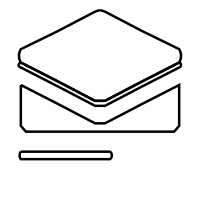

Generating Sample 4...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 13 . 9 1 . 4 15 . 8 1 . 8 17 . 4 2 . 7 C 18 . 9 3 . 5 20 . 3 4 . 8 21 . 3 6 . 5 C 22 . 4 8 . 3 22 . 8 10 . 2 22 . 8 12 . 1 C 22 . 7 13 . 9 22 . 2 15 . 7 21 . 3 17 . 3 C 20 . 4 18 . 9 19 . 1 20 . 3 17 . 5 21 . 3 C 15 . 9 22 . 2 14 . 0 22 . 8 12 . 0 22 . 8 C 10 . 0 22 . 8 8 . 1 22 . 2 6 . 5 21 . 3 C 4 . 9 20 . 3 3 . 6 18 . 9 2 . 7 17 . 3 C 1 . 8 15 . 7 1 . 3 13 . 9 1 . 2 12 . 1 C 1 . 2 10 . 2 1 . 6 8 . 3 2 . 7 6 . 5 C 3 . 7 4 . 8 5 . 1 3 . 5 6 . 6 2 . 7 C 8 . 2 1 . 8 10 . 1 1 . 4 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 5 L 12 . 0 2 . 5 C 13 .

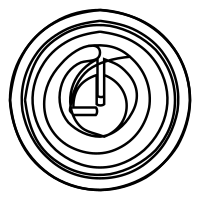

Generating Sample 5...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 6 L 12 . 0 2 . 6 C 12 . 2 2 . 7 12 . 4 2 . 8 12 . 6 2 . 9 L 15 . 5 5 . 9 L 18 . 3 8 . 9 C 18 . 6 9 . 6 18 . 6 10 . 0 17 . 8 10 . 3 L 12 . 0 10 . 3 L 6 . 3 10 . 3 C 5 . 5 10 . 0 5 . 5 9 . 6 5 . 8 8 . 9 L 8 . 6 5 . 9 L 11 . 4 2 . 9 C 11 . 6 2 . 8 11 . 8 2 . 7 12 . 0 2 . 6 L 12 . 0 2 . 6 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 7 . 3 11 . 0 L 12 . 0 11 . 0 L 16 . 7 11 . 0 C 17 . 6 11 . 3 17 . 6 12 . 0 16 . 7 12 . 3 L 12 . 0 12 . 3 L 7 . 3 12 . 3 C 6 . 6 12 . 0 6 . 6 11 . 3 7 . 3 11 . 0 L 7 . 3 11 . 0 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = "

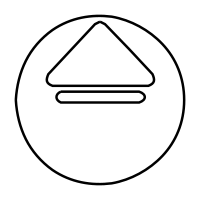

Generating Sample 6...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 5 L 12 . 0 2 . 5 C 14 . 2 2 . 8 15 . 8 3 . 6 17 . 0 4 . 8 C 18 . 2 6 . 0 18 . 9 7 . 6 19 . 2 9 . 9 L 19 . 2 11 . 3 L 20 . 7 16 . 5 C 21 . 2 19 . 0 20 . 4 20 . 2 17 . 9 20 . 8 L 12 . 0 20 . 8 L 6 . 1 20 . 8 C 3 . 6 20 . 2 2 . 8 19 . 0 3 . 3 16 . 5 L 4 . 7 11 . 3 L 4 . 8 9 . 9 C 5 . 0 7 . 5 5 . 8 5 . 4 7 . 2 4 . 0 C 8 . 6 2 . 7 10 . 7 2 . 0 13 . 2 2 . 4 L 13 . 2 2 . 4 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 10 . 7 4 . 2 L 13 . 3 4 . 2 C 15 . 4 5 . 0 15 . 5 6 . 4 13 . 5 7 . 3 L 10 . 7 7 . 3 C 8 . 5 6 . 4 8 . 5 4 . 9 10 . 7 4 . 2 L 10 . 7 4 . 2 " > < / path > < path fill = " none " stroke = " black " 

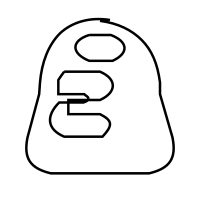

Generating Sample 7...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 4 . 2 L 12 . 0 4 . 2 C 14 . 2 4 . 3 16 . 1 4 . 5 18 . 0 5 . 6 C 19 . 7 6 . 6 20 . 8 8 . 0 21 . 3 9 . 4 C 21 . 8 10 . 9 21 . 7 12 . 5 20 . 9 14 . 0 C 20 . 2 15 . 5 19 . 0 16 . 9 17 . 4 18 . 0 C 15 . 8 19 . 1 14 . 1 19 . 6 12 . 2 19 . 6 C 9 . 7 19 . 7 7 . 4 18 . 7 5 . 8 17 . 1 C 4 . 1 15 . 5 3 . 1 13 . 3 2 . 9 11 . 0 C 2 . 7 8 . 7 3 . 5 6 . 4 5 . 3 4 . 6 C 7 . 0 2 . 9 9 . 0 2 . 4 11 . 4 2 . 2 L 11 . 4 2 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 6 3 . 3 L 11 . 6 3 . 3 C 13 . 1 3 . 4 15 . 1 3 . 7 16 . 3 4 . 9 C 16 . 8 5 . 4 17 . 1 6 . 1 17 . 3 6 . 8 C 17 . 4 7 . 3 17 . 4 8 . 1 17 . 0 8 . 1 C 16 . 3

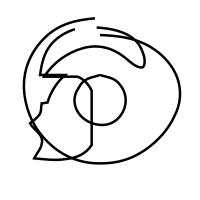

Generating Sample 8...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 1 5 . 0 L 11 . 1 5 . 0 C 11 . 5 5 . 2 11 . 9 5 . 5 12 . 3 5 . 8 L 12 . 3 11 . 7 L 17 . 2 11 . 7 C 17 . 5 12 . 1 18 . 0 12 . 3 18 . 0 12 . 7 C 18 . 0 13 . 1 17 . 5 13 . 3 17 . 2 13 . 6 L 12 . 3 13 . 6 L 12 . 3 18 . 2 C 11 . 9 18 . 5 11 . 7 19 . 0 11 . 1 19 . 0 C 10 . 7 19 . 0 10 . 5 18 . 5 10 . 2 18 . 2 L 10 . 2 13 . 6 L 6 . 8 13 . 6 C 6 . 5 13 . 3 6 . 0 13 . 1 6 . 0 12 . 7 C 6 . 0 12 . 3 6 . 5 12 . 1 6 . 8 11 . 7 L 10 . 2 11 . 7 L 10 . 2 5 . 8 C 10 . 5 5 . 5 10 . 9 5 . 2 11 . 1 5 . 0 L 11 . 1 5 . 0 " > < / path > < / svg >
post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/> <path fill="non

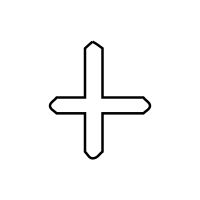

Generating Sample 9...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 13 . 9 1 . 4 15 . 8 1 . 8 17 . 4 2 . 7 C 18 . 9 3 . 5 20 . 3 4 . 8 21 . 3 6 . 5 C 22 . 4 8 . 3 22 . 8 10 . 2 22 . 8 12 . 1 C 22 . 7 13 . 9 22 . 2 15 . 7 21 . 3 17 . 3 C 20 . 4 18 . 9 19 . 1 20 . 3 17 . 5 21 . 3 C 15 . 9 22 . 2 14 . 0 22 . 8 12 . 0 22 . 8 C 10 . 0 22 . 8 8 . 1 22 . 2 6 . 5 21 . 3 C 4 . 9 20 . 3 3 . 6 18 . 9 2 . 7 17 . 3 C 1 . 8 15 . 7 1 . 3 13 . 9 1 . 2 12 . 1 C 1 . 2 10 . 2 1 . 6 8 . 3 2 . 7 6 . 5 C 3 . 7 4 . 8 5 . 1 3 . 5 6 . 6 2 . 7 C 8 . 2 1 . 8 10 . 1 1 . 4 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 6 L 12 . 0 2 . 6 C 13 .

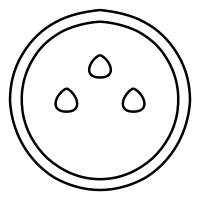

Generating Sample 10...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 6 L 12 . 0 2 . 6 C 14 . 1 2 . 7 15 . 9 3 . 3 17 . 4 4 . 2 C 19 . 0 5 . 1 20 . 3 6 . 3 21 . 3 8 . 2 C 22 . 0 9 . 4 23 . 1 12 . 5 21 . 5 13 . 4 L 15 . 2 13 . 4 L 8 . 9 13 . 4 L 2 . 6 13 . 4 C 0 . 9 12 . 5 0 . 8 9 . 4 2 . 6 8 . 2 C 3 . 7 7 . 5 5 . 0 7 . 7 6 . 6 7 . 9 C 8 . 1 8 . 1 9 . 7 8 . 3 10 . 6 7 . 4 L 10 . 6 6 . 6 L 9 . 3 6 . 6 C 9 . 1 6 . 5 9 . 1 6 . 1 9 . 3 5 . 9 L 11 . 3 3 . 9 C 11 . 3 3 . 9 11 . 4 3 . 8 11 . 4 3 . 8 L 11 . 4 3 . 8 C 11 . 6 3 . 6 11 . 8 3 . 4 12 . 0 3 . 2 L 12 . 0 3 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 10 . 3 12 . 0 L 10 . 3 12 . 0 C 10 . 4 11 . 7 10 . 6 11 . 4 10 . 

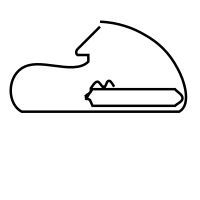

In [42]:
k = 10

print(f"\n--- Generating {k} Unconditional Samples ---")
unconditional_results = []
for i in range(k):
    print(f"Generating Sample {i+1}...")
    sample = generate_svg(
        target_model,
        tokenizer,
        prompt="<svg",
        max_new_tokens=TOKEN_THRESHOLD,
        temperature=0.7,
        top_k=5,
    )
    print(f"generated: {sample}")
    valid, rendered = evaluate_and_render(sample, f"xl_unconditional_{i}.png")
    unconditional_results.append((valid, rendered))

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 6.6 L 16.3 6.6 C 16.8 6.8 17.3 6.8 17.7 7.2 C 19.0 8.4 18.0 10.6 16.3 10.6 C 14.5 10.6 13.6 8.4 14.8 7.2 C 15.2 6.8 15.8 6.8 16.3 6.6 L 16.3 6.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.9 12.0 L 13.4 12.0 C 15.3 12.5 16.1 13.7 17.3 15.2 L 19.0 15.3 C 20

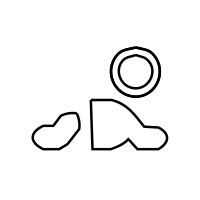

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 3.9 L 3.9 6.6 L 1.2 6.6 L 3.9 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 4.4 L 22.8 5.8 L 17.4 5.8 L 12.0 5.8 L 6.6 5.8 L 12.0 5.3 L 17.4 4.9 L 22.8 4.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.2 10.6 L 3.9 10.6 L 3.9 13.4 L 1.2 13.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 11.2 L 22.8 12.5 L 17.4 12.5 L 12.0 12.5 L 6.6 12.5 L 12.0 12.1 L 17.4 11.6 L 22.8 11.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 17.4 L 3.9 20.1 L 1.2 20.1 L 3.9 17.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 17.9 L 22.8 19.3 L 

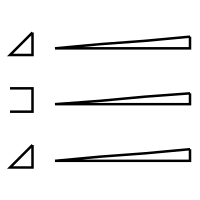

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 6.2 6.9 5.1 8.4 C 4.0 10.0 3.6 12.0 4.3 13.9 C 4.9 15.8 6.4 17.2 8.1 17.8 C 9.8 18.4 11.8 18.2 13.5 17.1 C 15.6 15.7 16.2 13.6 16.2 11.2 L 11.7 15.4 L 7.3 10.8 L 9.3 8.8 L 12.0 12.1 L 15.2 8.7 L 18.4 5.3 L 20.6 6.9 L 16.7 10.7 C 16.8 12.4 17.0 12.9 16.3 14.5 C 15.8 15.7 15.0 16.8 13.9 17.5 C 11.4 19.2 9.0 19.1 7.0 17.9 C 5.1 16.7 3.7 14.5 3.5 12.3 C 3.2 10.0 4.1 7.7 6.7 6.2 C 8.1 5.4 8.5 5.5 10.1 5.3 L 10.1 5.3"></path></svg>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 

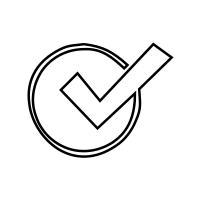

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.7 3.9 L 9.2 3.9 L 14.8 3.9 L 20.3 3.9 C 21.0 4.2 21.6 4.9 21.9 5.7 L 21.9 12.0 L 21.9 18.3 C 21.6 19.1 21.0 19.8 20.3 20.1 L 14.8 20.1 L 9.2 20.1 L 3.7 20.1 C 3.0 19.8 2.4 19.1 2.1 18.3 L 2.1 12.0 L 2.1 5.7 C 2.4 4.9 3.0 4.2 3.7 3.9 L 3.7 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 5.7 L 9.3 5.7 L 14.7 5.7 L 20.1 5.7 L 20.1 8.4 L 14.7 8.4 L 9.3 8.4 L 3.9 8.4 L 3.9 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 10.2 L 8.4 10.2 L 8.4 14.2 L 8.4 18.3 L 3.9 18.3 L 3.9 14.2 L 3.9 10.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.2 10.2 L 15.1 10.2 L 20.1 10.2 L 20.1 14.2 L 20.1 18.3 L 15.1 18.3 L 10.2 18.3 L 10.2 14.2 L 10.2 10.2"><

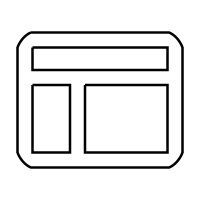

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 12.7 5.1 C 15.4 5.5 17.0 6.9 18.4 9.2 L 14.4 9.2 L 10.4 9.2 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 10.7 8.5 L 8.7 12.0 L 6.4 7.9 C 8.1 5.8 10.0 5.1 12.7 5.1 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.4 7.9 L 8.4 11.4 L 10.4 14.8 L 5.6 14.8 C 4.7 12.3 5.1 10.2 6.4 7.9 L 6.4 7.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 13.6 9.2 L 18.4 9.2 C 19.3 11.7 18.9 13.8 17.6 16.1 L 15.6 12.6 L 13.6 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 15.3 12.0 L 17.6 16.1 C 15.9 18.2 14.0 18.9 11.3 18.9 L 13.3 15.5 L 15.3 12.0"></path> <path fill="none" 

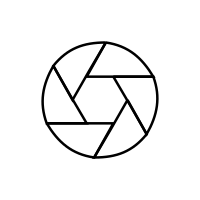

In [48]:
prefixes = []

ratio = 0.6

for i in range(5):
    s = filtered_test["Svg"][i]
    print(s)
    print(s[: int(len(s) * ratio)])

    display(SVG(s))
    # display(SVG(post_process_svg(s[:cap])))
    prefixes.append(s[: int(len(s) * ratio)])


--- Generating 5 Conditional Samples ---

Conditional 1 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 6.6 L 16.3 6.6 C 16.8 6.8 17.3 6.8 17.7 7.2 C 19.0 8.4 18.0 10.6 16.3 10.6 C 14.5 10.6 13.6 8.4 14.8 7.2 C 15.2 6.8 15.8 6.8 16.3 6.6 L 16.3 6.6"></path> <path fill="none" stroke...):
len(prefix): 865
< svg xmlns = " http : / / www . w3 . org / 20

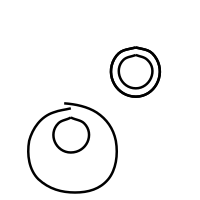


Conditional 2 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 3.9 L 3.9 6.6 L 1.2 6.6 L 3.9 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 4.4 L 22.8 5.8 L 17.4 5.8 L 12.0 5.8 L 6.6 5.8 L 12.0 5.3 L 17.4 4.9 L 22.8 4.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.2 10.6 L 3.9 10.6 L 3.9 13.4 L 1.2 13.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8...):
len(prefix): 649
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 9 3 . 9 L 3 . 9 6 . 6 L 1 . 2 6 . 6 L 3 . 9 

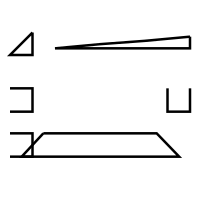


Conditional 3 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 6.2 6.9 5.1 8.4 C 4.0 10.0 3.6 12.0 4.3 13.9 C 4.9 15.8 6.4 17.2 8.1 17.8 C 9.8 18.4 11.8 18.2 13.5 17.1 C 15.6 15.7 16.2 13.6 16.2 11.2 L 11.7...):
len(prefix): 428
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 10 . 1 5 . 3 L 10 . 1 5 . 3 C 12 . 4 5 . 6 13 . 5 6 . 2 15 . 3 7 . 8 L 14 . 9 8 . 2 C 13 . 5 6 . 9 12 . 2 5 . 8 10 . 1 5 . 9 C 8 . 0 5 . 9 6 . 2 6 . 9 5 . 1 8 . 4 C 4 . 0 10 . 0 3 . 6 12 . 0 4 . 3 13 . 9 C 4 . 9 15 . 8 6 . 4 17 . 2 8 . 1 17 . 8 C 9 . 8 18 . 4 11 . 8 18

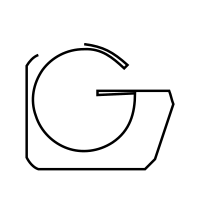


Conditional 4 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.7 3.9 L 9.2 3.9 L 14.8 3.9 L 20.3 3.9 C 21.0 4.2 21.6 4.9 21.9 5.7 L 21.9 12.0 L 21.9 18.3 C 21.6 19.1 21.0 19.8 20.3 20.1 L 14.8 20.1 L 9.2 20.1 L 3.7 20.1 C 3.0 19.8 2.4 19.1 2.1 18.3 L 2.1 12.0 L 2.1 5.7 C 2.4 4.9 3.0 4.2 3.7 3.9 L 3.7 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 5.7 L 9.3 5.7 L 14.7 5.7 L 20.1 5.7 L 20.1 8.4 L 14.7 8.4 L 9.3 8.4 L 3.9 ...):
len(prefix): 607
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 7 3 . 9 L 9 . 2 3 . 9 L 14 . 8 3 . 9 L 20 . 3 3 . 9 C 21 . 0 4 . 2 21 . 6 4 . 9 21 . 9

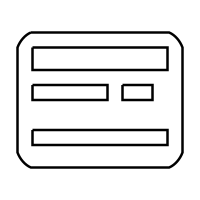


Conditional 5 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 12.7 5.1 C 15.4 5.5 17.0 6.9 18.4 9.2 L 14.4 9.2 L 10.4 9.2 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 10.7 8.5 L 8.7 12.0 L 6.4 7.9 C 8.1 5.8 10.0 5.1 12.7 5.1 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.4 7.9 L 8.4 11.4 L 10.4 14.8 L 5.6 14.8 C 4.7 12.3 5.1 10.2 6.4 7.9 L 6.4 7.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1...):
len(prefix): 701
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = 

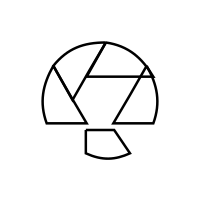

In [49]:
print("\n--- Generating 5 Conditional Samples ---")

conditional_results = []
for i, prefix in enumerate(prefixes):
    print(f"\nConditional {i+1} (Prompt: {prefix}...):")

    print(f"len(prefix): {len(prefix)}")
    sample = generate_svg(
        target_model,
        tokenizer,
        prompt=prefix,
        max_new_tokens=TOKEN_THRESHOLD,
        temperature=0.7,
        top_k=5,
    )
    print(sample)
    valid, rendered = evaluate_and_render(sample, f"conditional_{i}.png")
    conditional_results.append((valid, rendered))

In [50]:
xml_valid_uncond = sum([1 for v, r in unconditional_results if v])
rendered_uncond = sum([1 for v, r in unconditional_results if r])

xml_valid_cond = sum([1 for v, r in conditional_results if v])
rendered_cond = sum([1 for v, r in conditional_results if r])

print(f"\n{'='*40}")
print(f"XL MODEL GENERATION SUMMARY")
print(f"{'='*40}")
print(f"Unconditional: {xml_valid_uncond}/10 Valid XML | {rendered_uncond}/10 Rendered")
print(f"Conditional:   {xml_valid_cond}/5 Valid XML | {rendered_cond}/5 Rendered")


XL MODEL GENERATION SUMMARY
Unconditional: 10/10 Valid XML | 10/10 Rendered
Conditional:   5/5 Valid XML | 5/5 Rendered
